### importing libraries

In [1]:
import sklearn
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_error
from matplotlib import pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import re
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
sklearn.__version__

'1.6.1'

In [3]:
!pip install google-generativeai

In [4]:
!pip install --upgrade google-generativeai

In [41]:
import google.generativeai as genai

# 🔐 Configure your Gemini API key
genai.configure(api_key="API Key")

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### data loading

In [7]:
df=pd.read_csv('/content/drive/MyDrive/combined_social_data_features.csv')

In [8]:
df.head(5)

,account_name,caption,comment_count,share_count,like_count,platform,hashtags,mentions,engagement_score,caption_length,word_count,sentiment_score,hashtag_count,mention_count
0,McDonald's,SWIPE TO SEE WHAT PRIZES ARE LEFT!!! IT’S NOT ...,128,31,299,Facebook,NaN,NaN,458,149,29,0.303516,0,0
1,McDonald's,6 episodes\n25 Grimace family members\n1 wacky...,413,59,462,Facebook,NaN,NaN,934,92,16,0.425000,0,0
2,McDonald's,my dms can rest now,612,33,393,Facebook,NaN,NaN,1038,19,5,0.000000,0,0
3,McDonald's,MONOPOLY IS BACK AT McD’S! AVAILABLE ALL DAY! ...,1781,792,2677,Facebook,NaN,NaN,5250,122,23,0.195833,0,0
4,McDonald's,it all started with a McDonald's napkin... a s...,271,71,363,Facebook,NaN,NaN,705,117,19,0.000000,0,0


### checking null values

In [9]:
df.isnull().sum()

,0
account_name,0
caption,0
comment_count,0
share_count,0
like_count,0
platform,0
hashtags,1044
mentions,1044
engagement_score,0
caption_length,0


### heatmap
**we are going to plot Correlation heatmap to visualiza Correlation between columns**

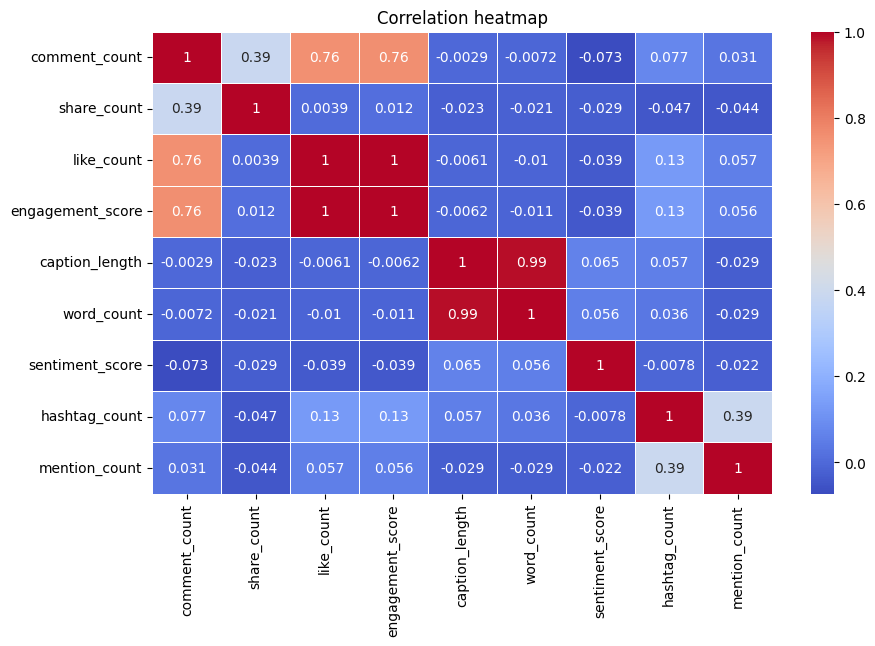

In [10]:
num_df = df.select_dtypes(include = ["int64", "float64"])
plt.figure(figsize =(10,6))
sns.heatmap(num_df.corr(), annot = True, cmap= "coolwarm", linewidth = 0.5)
plt.title("Correlation heatmap")
plt.show()

### cleaning caption
**now we are going to work on caption column**

In [11]:
import re
from nltk.corpus import stopwords

def clean_caption(text):
    stop = set(stopwords.words('english'))

    text = str(text).lower()                                # lowercase
    text = re.sub(r'http\S+|www\S+', '', text)              # remove URLs
    text = re.sub(r'\n', ' ', text)                         # remove newlines
    text = re.sub(r'[^\w\s]', '', text)                     # remove punctuation
    text = re.sub(r'\d+', '', text)                         # remove numbers
    text = re.sub(r'\s+', ' ', text).strip()                # remove extra spaces
    text = ' '.join([word for word in text.split() if word not in stop])  # remove stopwords

    return text

# Apply function to your column
df['caption'] = df['caption'].apply(clean_caption)


### dropping cols

In [12]:
df = df.drop(['share_count', 'mentions', 'hashtags','hashtag_count','mention_count'], axis=1)

### calculating engagement score

In [13]:
df["engagement_score"]=df["like_count"]+df["comment_count"]

### top brands by engagement score

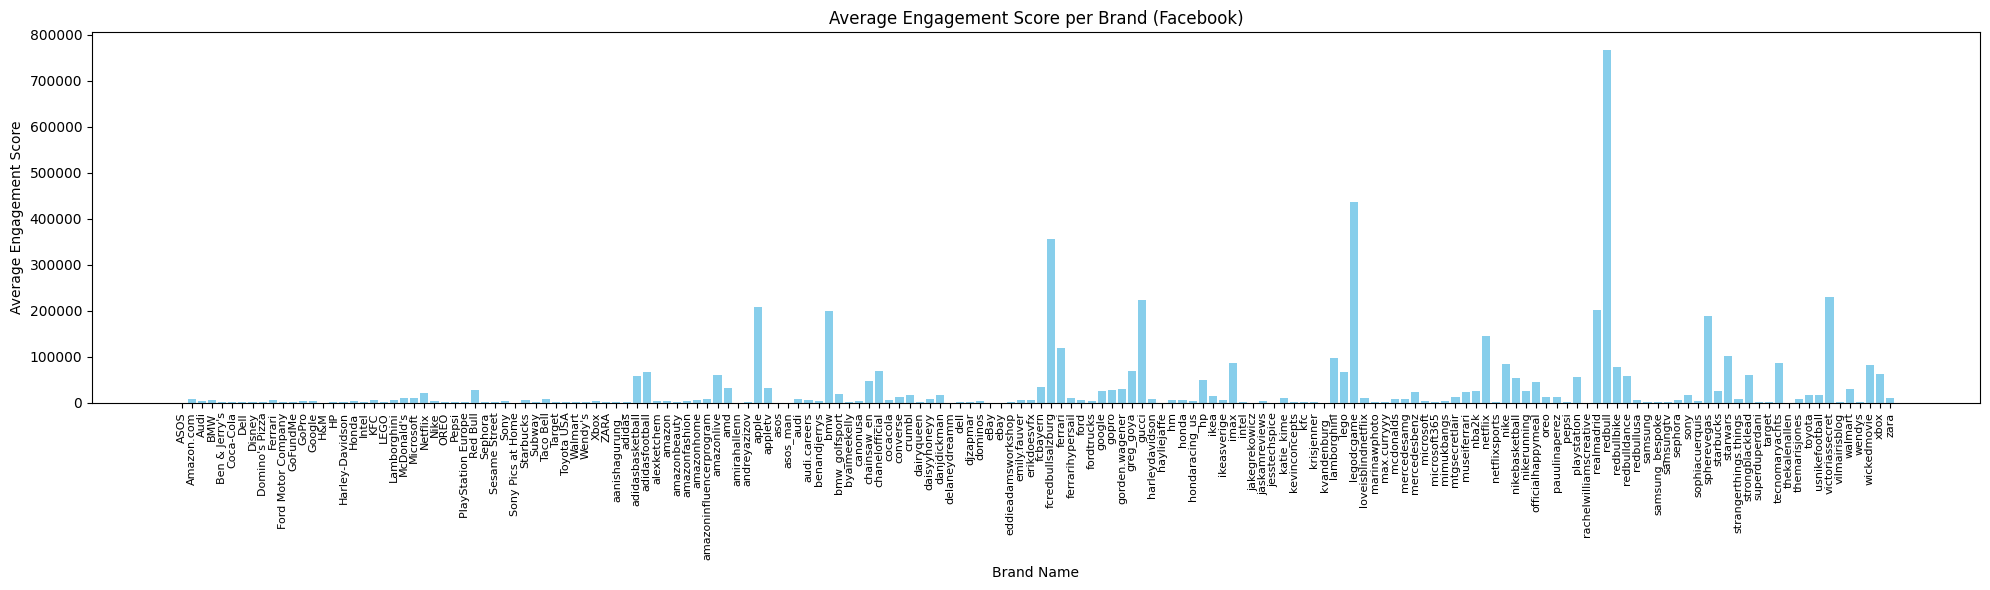

In [14]:
brand_engagement = df.groupby('account_name')['engagement_score'].mean().reset_index()

# Plot
plt.figure(figsize=(20,6))  # wider figure for more labels
plt.bar(brand_engagement['account_name'], brand_engagement['engagement_score'], color='skyblue')

plt.xlabel('Brand Name')
plt.ylabel('Average Engagement Score')
plt.title('Average Engagement Score per Brand (Facebook)')
plt.xticks(rotation=90, fontsize=8)  # rotate and shrink font
plt.tight_layout()
plt.show()

## top 20 brands

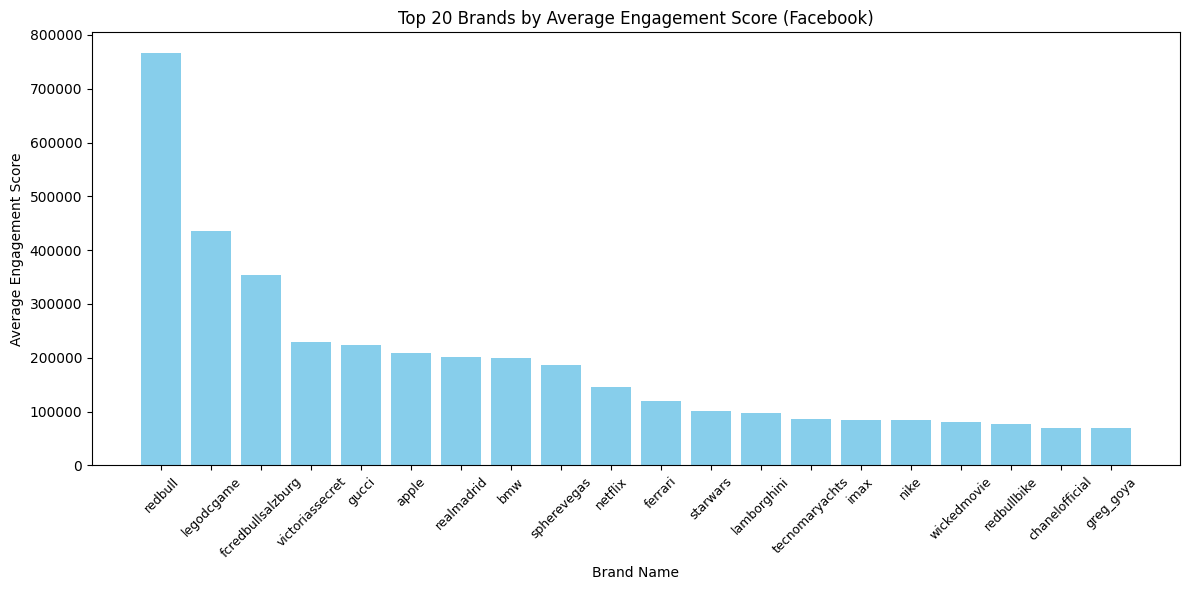

In [15]:
brand_engagement = df.groupby('account_name')['engagement_score'].mean().reset_index()

# sort and select top 20
top20 = brand_engagement.sort_values(by='engagement_score', ascending=False).head(20)

# Plot
plt.figure(figsize=(12,6))
plt.bar(top20['account_name'], top20['engagement_score'], color='skyblue')

plt.xlabel('Brand Name')
plt.ylabel('Average Engagement Score')
plt.title('Top 20 Brands by Average Engagement Score (Facebook)')
plt.xticks(rotation=45, fontsize=9)
plt.tight_layout()
plt.show()


## dealing with  outliers
####  **we noticed that we have outlyers in columns. now we will chk is iqr triming or iqr capping working good on outlyers. later we will use it for like and comment also**

### 1. engagement score

In [16]:
lower_power=df['engagement_score'].quantile(0.25)
uper_power=df['engagement_score'].quantile(0.75)
iqr=uper_power-lower_power

In [17]:
upper_limit=uper_power+1.5*iqr
lower_limit=lower_power-1.5*iqr

In [18]:
#using iqr capping method
new_df_cap=df.copy()
new_df_cap['engagement_score']=np.where(
    new_df_cap['engagement_score']>upper_limit,
    upper_limit,
    np.where(
        new_df_cap['engagement_score']<lower_limit,
        lower_limit,
        new_df_cap['engagement_score']
    )

)


## visualization

#### box plot for engagement score after & before imputing outliers

/tmp/ipython-input-196828629.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['engagement_score'])
/tmp/ipython-input-196828629.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(new_df_cap['engagement_score'])


{'whiskers': [<matplotlib.lines.Line2D at 0x7d3bb4605eb0>,
 'caps': [<matplotlib.lines.Line2D at 0x7d3bb4606480>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d3bb478e6c0>],
 'medians': [<matplotlib.lines.Line2D at 0x7d3bbc192000>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d3bb4606b70>],
 'means': []}

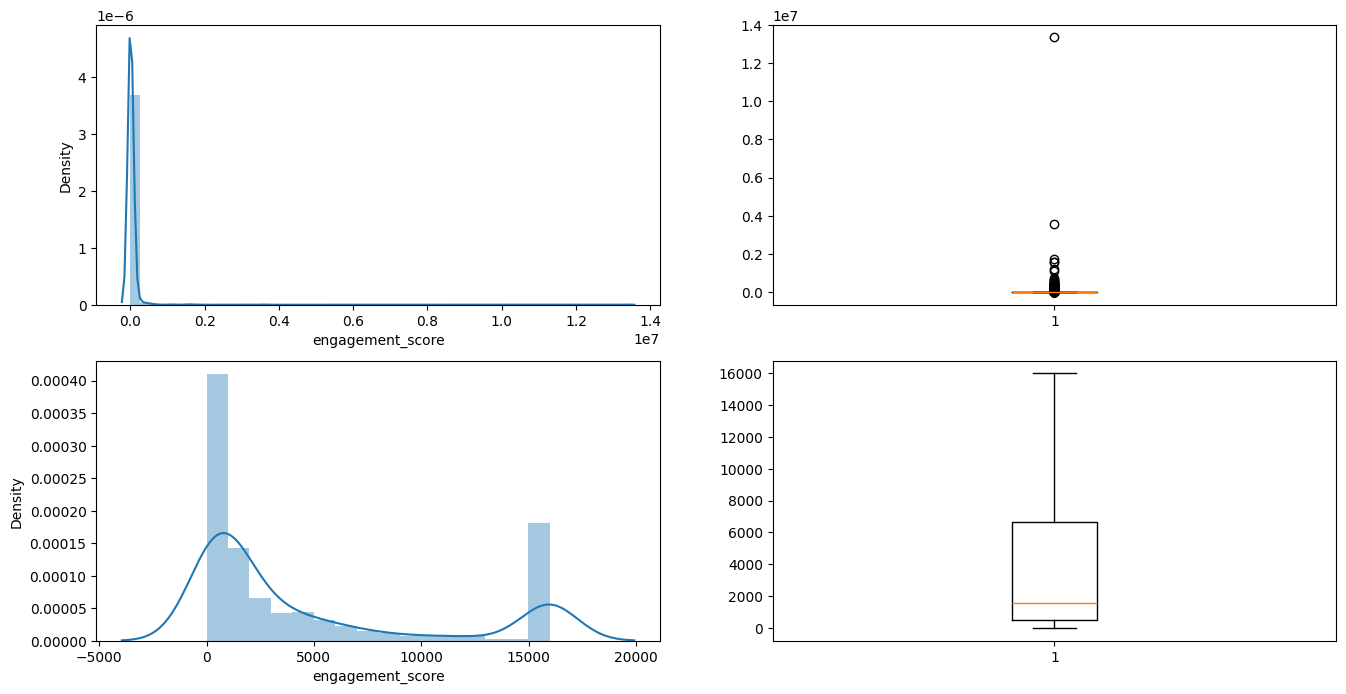

In [19]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
sns.distplot(df['engagement_score'])
plt.subplot(2,2,2)
plt.boxplot(df['engagement_score'])
plt.subplot(2,2,3)
sns.distplot(new_df_cap['engagement_score'])
plt.subplot(2,2,4)
plt.boxplot(new_df_cap['engagement_score'])

### 2. like count

In [20]:
lower_power=new_df_cap['like_count'].quantile(0.25)
uper_power=new_df_cap['like_count'].quantile(0.75)
iqr=uper_power-lower_power


In [21]:
upper_limit=uper_power+1.5*iqr
lower_limit=lower_power-1.5*iqr

In [22]:
#using iqr capping method
newDf=new_df_cap.copy()
newDf['like_count']=np.where(
    newDf['like_count']>upper_limit,
    upper_limit,
    np.where(
        newDf['like_count']<lower_limit,
        lower_limit,
        newDf['like_count']
    )

)


### visualizing like-count after and before outliers

{'whiskers': [<matplotlib.lines.Line2D at 0x7d3bb46db2f0>,
 'caps': [<matplotlib.lines.Line2D at 0x7d3bb46db890>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d3bb46dafc0>],
 'medians': [<matplotlib.lines.Line2D at 0x7d3bb46dbef0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d3bb45001d0>],
 'means': []}

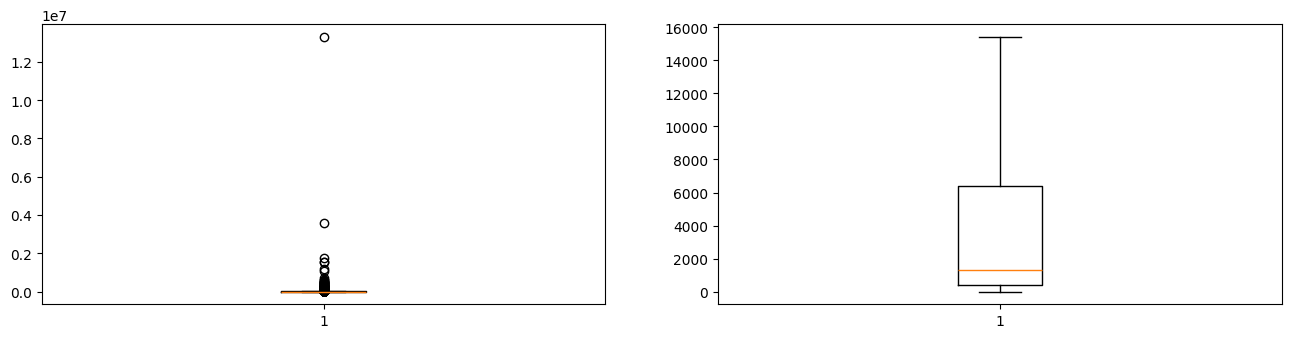

In [23]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
plt.boxplot(df['like_count'])
plt.subplot(2,2,2)
plt.boxplot(newDf['like_count'])

### 3. for comment count

In [24]:
lower_power=newDf['comment_count'].quantile(0.25)
uper_power=newDf['comment_count'].quantile(0.75)
iqr=uper_power-lower_power

In [25]:
upper_limit=uper_power+1.5*iqr
lower_limit=lower_power-1.5*iqr

In [26]:
#using iqr capping method
Df=newDf.copy()
Df['comment_count']=np.where(
    Df['comment_count']>upper_limit,
    upper_limit,
    np.where(
     Df['comment_count']<lower_limit,
        lower_limit,
        Df['comment_count']
    )

)

### visualizing comment_count after and before imputing outliers

{'whiskers': [<matplotlib.lines.Line2D at 0x7d3bb45b4800>,
 'caps': [<matplotlib.lines.Line2D at 0x7d3bb45b4e00>,
 'boxes': [<matplotlib.lines.Line2D at 0x7d3bb45b4500>],
 'medians': [<matplotlib.lines.Line2D at 0x7d3bb45b5400>],
 'fliers': [<matplotlib.lines.Line2D at 0x7d3bb45b56d0>],
 'means': []}

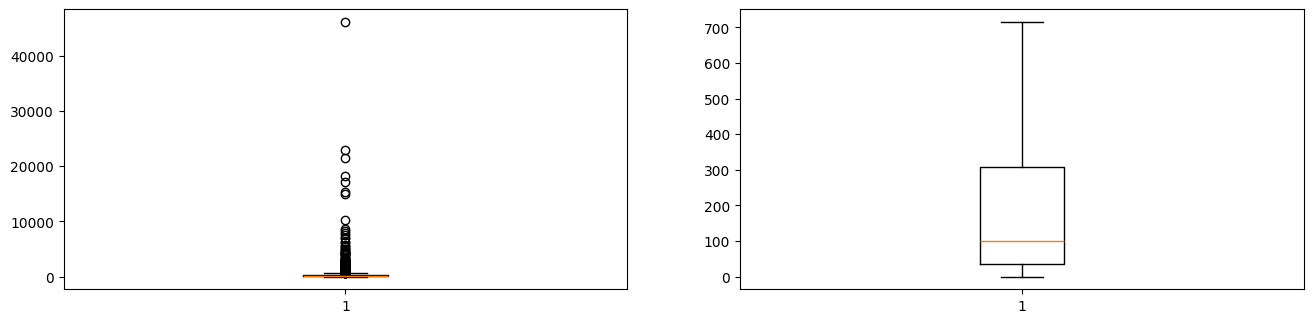

In [27]:
plt.figure(figsize=(16,8))
plt.subplot(2,2,1)
plt.boxplot(df['comment_count'])
plt.subplot(2,2,2)
plt.boxplot(Df['comment_count'])

## heatmap after outliers

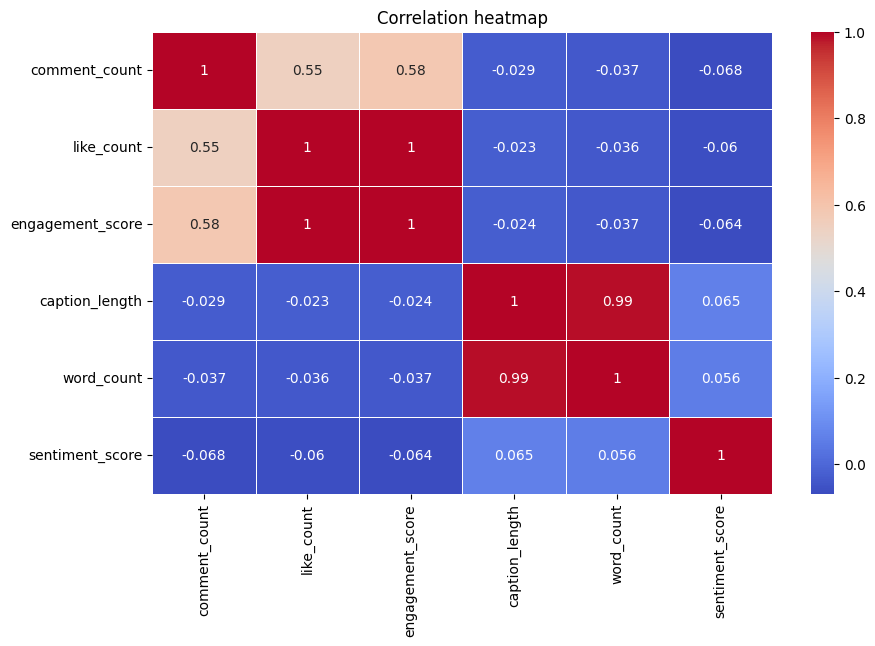

In [28]:
num_df = Df.select_dtypes(include = ["int64", "float64"])
plt.figure(figsize =(10,6))
sns.heatmap(num_df.corr(), annot = True, cmap= "coolwarm", linewidth = 0.5)
plt.title("Correlation heatmap")
plt.show()

## Model Training

#### train test split

In [29]:
X=Df.drop(['engagement_score'],axis=1)
Y=Df['engagement_score']

In [30]:
X_train, X_test, Y_train, Y_test= train_test_split(X,Y, test_size=0.2, random_state=42)
X_train

,account_name,caption,comment_count,like_count,platform,caption_length,word_count,sentiment_score
1733,honda,iconic honda prelude making return visit link ...,715.0,15419.0,Instagram,82,16,0.500000
1556,xbox,take favorite games wherever rog xbox ally rog...,715.0,15419.0,Instagram,111,21,0.500000
1641,gopro,rescuing baby shark goproawards recipient vinc...,112.0,15419.0,Instagram,315,49,0.250000
175,Wendy's,little allways went wendys school nd streeet s...,715.0,2521.0,Facebook,172,36,-0.138393
1102,target,laurenwolfe takes us behind scenes woolrich ta...,4.0,460.0,Instagram,189,29,-0.142857
...,...,...,...,...,...,...,...,...
1130,walmart,heard deals coming oct right hearing right,40.0,372.0,Instagram,74,13,0.285714
1294,starbucks,favorite drink add protein,238.0,4297.0,Instagram,37,6,0.500000
860,Amazon.com,eyes sameday delivery amazondelivery skeletons...,715.0,12985.0,Facebook,76,9,0.000000
1459,apple,lets dance commissioned apple new iphone pro b...,488.0,15419.0,Instagram,196,29,0.136364


#### now we are going to use columntransformer to handle all columns. under the ColumnTransformer we will use vectorization and one hotencoder for our non numeric columns

In [31]:
preprocessor = ColumnTransformer(
    transformers=[
        # 1️⃣ Apply TF-IDF on caption
        ('tfidf', TfidfVectorizer(stop_words='english'), 'caption'),

        # 2️⃣ One-Hot Encode account_name & platform
        ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'),
         ['account_name', 'platform']),

        # 3️⃣ Pass numeric columns as they are
        ('num', 'passthrough',
         ['comment_count', 'like_count', 'caption_length', 'word_count', 'sentiment_score'])
    ]
)

##### making a pipeline for columntransformer and algorithm fiting

In [32]:
model = Pipeline(steps=[
    ('preprocess', preprocessor),   # your ColumnTransformer
    ('rf', RandomForestRegressor(random_state=42))
])

### model training

In [33]:
model.fit(X_train, Y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('tfidf',
                                                  TfidfVectorizer(stop_words='english'),
                                                  'caption'),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['account_name', 'platform']),
                                                 ('num', 'passthrough',
                                                  ['comment_count',
                                                   'like_count',
                                                   'caption_length',
                                                   'word_count',
                                                   'sentiment_score'])])),
                ('rf', RandomForestRegressor(random_state=42))])

In [34]:
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


In [35]:
y_pred

array([1.59751250e+04, 2.26350000e+02, 1.59751250e+04, 5.63800000e+02,
       6.19005000e+03, 1.35159000e+03, 5.22733000e+03, 2.83705000e+03,
       4.25330000e+02, 1.59713438e+04, 9.58400000e+01, 6.70763000e+03,
       5.22717000e+03, 1.59751250e+04, 3.29708000e+03, 9.56500000e+01,
       1.27800000e+02, 1.83756000e+03, 3.54100000e+01, 9.45950000e+02,
       6.26080000e+02, 1.59751250e+04, 8.81230000e+02, 1.85252000e+03,
       1.59551100e+04, 1.50653000e+03, 8.83160000e+02, 1.74330000e+02,
       5.08794000e+03, 2.44637000e+03, 1.59751250e+04, 2.80170000e+02,
       2.14688000e+03, 1.45287000e+03, 1.68532000e+03, 8.53510000e+02,
       5.82870000e+02, 1.59751250e+04, 2.36052000e+03, 6.86900000e+02,
       1.59751250e+04, 7.86510000e+02, 3.57455000e+03, 4.20716000e+03,
       6.44969000e+03, 5.72407000e+03, 4.45890000e+02, 8.59230000e+02,
       1.49960000e+02, 1.00065800e+04, 6.48450000e+02, 9.97427000e+03,
       4.82670000e+02, 3.86616000e+03, 4.66910000e+02, 1.39895000e+03,
      

In [42]:
def get_gemini_suggestions(caption, engagement_score):
    prompt = f"""
I have a social media post with the following:
Caption: {caption}
Predicted Engagement Score: {engagement_score}

Provide:
1. Explanation
2. Suggestions
3. Improved caption
4. Hashtags
"""

    # 👉 FIX: DO NOT use the name 'model' here
    gemini_model = genai.GenerativeModel("gemini-pro-latest")

    response = gemini_model.generate_content(prompt)
    return response.text

In [43]:
def predict_with_gemini(caption,
                        account_name,
                        platform,
                        comment_count,
                        like_count,
                        caption_length,
                        word_count,
                        sentiment_score):
    """
    Takes raw features for ONE new post,
    uses your trained ML model + Gemini to generate full analysis.
    """

    # Build input row
    new_data = pd.DataFrame([{
        "caption": caption,
        "account_name": account_name,
        "platform": platform,
        "comment_count": comment_count,
        "like_count": like_count,
        "caption_length": caption_length,
        "word_count": word_count,
        "sentiment_score": sentiment_score
    }])

    # 1️⃣ Predict engagement score with RandomForest model
    predicted_score = model.predict(new_data)[0]

    # 2️⃣ Get Gemini suggestions based on caption + score
    gemini_output = get_gemini_suggestions(caption, predicted_score)

    return predicted_score, gemini_output

### model evaluation

In [44]:
print("MSE:", mean_squared_error(Y_test, y_pred))
print("R2 Score:", r2_score(Y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, y_pred)))
print("MAE:", mean_absolute_error(Y_test, y_pred))


MSE: 42986.902523328994
R2 Score: 0.9985938005754236
RMSE: 207.3328303075251
MAE: 60.00702430555555


### downloading model

In [39]:
import pickle
print("Saving the model...")
with open('ads_predictor.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)
print("Model saved successfully!")

Saving the model...
Model saved successfully!


In [45]:
# Reset index so we can access rows easily
X_test_reset = X_test.reset_index(drop=True)

results = []

# 🔹 You can change 5 to 10 or more if you want more Gemini outputs
n_examples = min(5, len(X_test_reset))

for i in range(n_examples):
    row = X_test_reset.loc[i]
    caption = row['caption']
    predicted_score = y_pred[i]

    gemini_output = get_gemini_suggestions(caption, predicted_score)

    results.append({
        "caption": caption,
        "predicted_engagement": predicted_score,
        "gemini_response": gemini_output
    })

results_df = pd.DataFrame(results)
results_df

,caption,predicted_engagement,gemini_response
0,cue slow clap,15975.125,"Of course! Based on your social media post, he..."
1,menu items nytgames,226.350,Of course. Here is a breakdown of your social ...
2,hope enjoy trailer carol pluribus premieres no...,15975.125,Of course. Here is a detailed breakdown based ...
3,tune carolina milanesi creative strategies sha...,563.800,Of course. Here is a full breakdown based on y...
4,slice right hit hard fast advanced aerodynamic...,6190.050,Of course. Here is a breakdown of the provided...
